In [130]:
import polars as pl
import pandas as pd
import numpy as np
import altair as alt
import pyarrow
from numpy.ma.extras import unique
from polars import Null
import matplotlib.pyplot as plt
import squarify
import seaborn as sns

from func.UsefulFunctions import *

This notebook documents the cleaning and inspection process for the artist data on wikidata

In [131]:
artistDF = pl.read_parquet("./Data/pipelinesArtistsWikidata.parquet")
print(f"There are {len(artistDF["artist"].unique())} unique artist entities after the removal of the disallowed occupations.")
display(artistDF.head(3))

There are 444888 unique artist entities after the removal of the disallowed occupations.


artist,occupation,gender,occupationLabel,genderLabel,countryCitizenship,influencedBY,influencedBYLabel,statementCount,genre,article,musicBrainzID,recordLabel,recordLabelLabel,countryCitizenshipLabel,genreLabel,artistLabel
str,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str
"""Q7161""","""Q36834""","""Q6581097""","""composer""","""male""","""Q29""",null,null,null,"""Q1413570""","""https://en.wikipedia.org/wiki/…","""533761c0-61cd-4d0e-b264-c71d5d…",null,null,"""Spain""","""sardana""","""José María Ventura Casas"""
"""Q7241""","""Q36834""","""Q6581097""","""composer""","""male""","""Q129286""",null,null,538.0,null,"""https://en.wikipedia.org/wiki/…","""13274b60-181b-431a-b049-b48560…",null,null,"""British Raj""",null,"""Rabindranath Tagore"""
"""Q7241""","""Q36834""","""Q6581097""","""composer""","""male""","""Q129286""",null,null,538.0,null,"""https://en.wikipedia.org/wiki/…","""13274b60-181b-431a-b049-b48560…",null,null,"""British Raj""",null,"""Rabindranath Tagore"""


In [132]:
#inspect the different fields in the system that are error prone
#see the different genders in the dataframe
print(artistDF[["artist","genderLabel"]].unique().select(pl.col("genderLabel").value_counts(sort=True)).unnest("genderLabel"))
print(artistDF[["genderLabel"]].unique().select(pl.col("genderLabel")).to_series().to_list())

#see some genders who have unknown or none gender
noGender = artistDF.filter(
    pl.col("gender").is_null()
)
noGender = noGender.select(pl.col(["artist","gender","genderLabel"])).unique()
print(noGender)
#Save the file for individuals who do not have a gender
noGender.write_csv("./missingValuesStore/artistsEntitiesWithoutGenders.csv",)


shape: (30, 2)
┌──────────────────┬────────┐
│ genderLabel      ┆ count  │
│ ---              ┆ ---    │
│ str              ┆ u32    │
╞══════════════════╪════════╡
│ male             ┆ 331681 │
│ female           ┆ 112112 │
│ non-binary       ┆ 472    │
│ trans woman      ┆ 471    │
│ trans man        ┆ 107    │
│ …                ┆ …      │
│ demigirl         ┆ 1      │
│ apagender        ┆ 1      │
│ non-binary woman ┆ 1      │
│ gender agnostic  ┆ 1      │
│ demiboy          ┆ 1      │
└──────────────────┴────────┘
['female', 'demiboy', 'undisclosed gender', 'bigender', 'transfeminine', 'apagender', 'intersex woman', 'intersex trans woman', 'cisgender woman', 'male', 'takatāpui', 'agender', 'demigirl', 'genderqueer', 'travesti', 'cisgender man', 'genderfluid', 'intersex man', 'trans man', 'androgyne', 'transgender', 'transmasculine', 'non-binary woman', 'gender agnostic', 'intersex', 'non-binary', None, 'trans woman', 'two-spirit', 'neutral sex']
shape: (41, 3)
┌────────────┬──────

Checked the genders to ensure that error/unknown genders were successfully nulled.

In [133]:
#Null the artist labels for the individuals who do not have an artist label

noNames = artistDF.filter(
    pl.col("artist").is_in(pl.col("artistLabel").implode())
).select(pl.col("artistLabel")).unique()
name_dict = {k: None for k in noNames["artistLabel"].to_list()}
artistDF = artistDF.with_columns(pl.col("artistLabel").replace(name_dict))

noNamesDF = artistDF.filter(
    pl.col("artistLabel").is_null(),
).select(pl.col(["artist","artistLabel"])).unique()
display(noNamesDF)
print(f"There are {len(noNamesDF)} artists with no default labels/labels in english.")
noNamesDF.write_csv("./missingValuesStore/artistsEntitiesWithoutLabels.csv")

artist,artistLabel
str,str
"""Q112021856""",null
"""Q61134755""",null
"""Q19909122""",null
"""Q12082817""",null
"""Q136736462""",null
…,…
"""Q12121968""",null
"""Q22773616""",null
"""Q139440889""",null


There are 14131 artists with no default labels/labels in english.


In [134]:
#The individuals with a country without an english label
#First let's see if there are any unknown or erroneous countries by using the Q-numbers and there are
artistDF.filter(
    pl.col('countryCitizenshipLabel').str.starts_with("Q")
).select(pl.col('countryCitizenshipLabel')).unique().to_series().to_list()

noLabel_Country = artistDF.filter(
    pl.col("countryCitizenship").is_in(pl.col("countryCitizenshipLabel").implode())
).select(pl.col("countryCitizenshipLabel")).unique()
countryName_dict = {k: None for k in noLabel_Country["countryCitizenshipLabel"].to_list()}
artistDF = artistDF.with_columns(pl.col("countryCitizenshipLabel").replace(countryName_dict))
artistDF = artistDF.with_columns(
    countryCitizenship = pl.when(~pl.col('countryCitizenship').str.starts_with("Q")).then(None).otherwise(pl.col('countryCitizenship'))
)
noCountryLabel = artistDF.filter(
    pl.col("countryCitizenshipLabel").is_null(),
).select(pl.col(["countryCitizenship","countryCitizenshipLabel"])).unique()
display(noCountryLabel)
# noCountry = artistDF.filter(
#     pl.col("countryCitizenship").is_in(pl.col("countryCitizenshipLabel").implode())
# ).select(pl.col("countryCitizenship")).unique()
# display(noCountry)
# print(f"There are {len(noCountry)} artists with a country with no labels. These will be cleaned out.")
# noCountry.write_csv("./missingValuesStore/artistsEntitiesWithoutLabelledCountries.csv")

countryCitizenship,countryCitizenshipLabel
str,str
"""Q2181059""",null
null,null
"""Q20581158""",null


In [135]:
#Genres with no labels in english/default language
noGenre = artistDF.filter(
    pl.col("genre").is_in(pl.col("genreLabel").implode())
).select(pl.col('genreLabel')).unique()
noGenreName_dict = {k: None for k in noGenre["genreLabel"].to_list()}
artistDF = artistDF.with_columns(pl.col("genreLabel").replace(noGenreName_dict))
artistDF = artistDF.with_columns(
    genre = pl.when(~pl.col('genre').str.starts_with("Q")).then(None).otherwise(pl.col('genre'))
)

noGenreLabel = artistDF.filter(
    pl.col("genreLabel").is_null(),
).select(pl.col(["artist","artistLabel","genre","genreLabel"])).unique()
display(noGenreLabel)
#print(f"There are {len(noGenre)} artists with a genre with no labels. These will be cleaned out.")
noGenreLabel.write_csv("./missingValuesStore/artistsEntitiesWithoutLabelledGenresOrNoGenres.csv")

artist,artistLabel,genre,genreLabel
str,str,str,str
"""Q2643001""","""Alexander Schubert""",null,null
"""Q117830695""","""Yuna""",null,null
"""Q55143841""","""Joan Aranyes""",null,null
"""Q1245136""","""Bruce Forsyth""",null,null
"""Q10393808""","""Wilson Miranda""",null,null
…,…,…,…
"""Q316074""","""Cipriano de Rore""",null,null
"""Q2526634""","""Vincent LaDuke""",null,null
"""Q71726409""","""Kalina Vladovska""",null,null


In [136]:
#Record Labels without a label
noRecordLabelLabel = artistDF.filter(
    pl.col("recordLabel").is_in(pl.col("recordLabelLabel").implode())
).select(pl.col(["recordLabelLabel"])).unique()
recordLabel_dict = {k: None for k in noRecordLabelLabel["recordLabelLabel"].to_list()}
artistDF = artistDF.with_columns(
    pl.col("recordLabelLabel").replace(recordLabel_dict),
    recordLabel = pl.when(~pl.col('recordLabel').str.starts_with("Q")).then(None).otherwise(pl.col('recordLabel')),
)

recordLabelsWithNoLabel = artistDF.filter(
    pl.col("recordLabelLabel").is_null()
).select(["artist","artistLabel","recordLabel","recordLabelLabel"]).unique()
display(recordLabelsWithNoLabel)

recordLabelsWithNoLabel.write_csv("./missingValuesStore/artistsEntitiesWithoutLabelledRecordLabelsOrNoRecordLabels.csv")

artist,artistLabel,recordLabel,recordLabelLabel
str,str,str,str
"""Q137012975""","""Thomas Körber""",null,null
"""Q54586554""","""Gilberto""",null,null
"""Q112488163""","""R. V. Tabb""",null,null
"""Q16179072""","""Ronald Gustav""",null,null
"""Q28045011""","""Terry James""",null,null
…,…,…,…
"""Q85974715""","""Allan Withington""",null,null
"""Q1243604""","""Justus Hermann Wetzel""",null,null
"""Q116464215""","""Yuri Galstyan""",null,null


In [137]:
#Influences Labels without a label
noLabelsInfluencedBY = artistDF.filter(
    pl.col("influencedBY").is_in(pl.col("influencedBYLabel").implode())
).select(pl.col(["influencedBYLabel"])).unique()

influencedBName_dict = {k: None for k in noLabelsInfluencedBY["influencedBYLabel"].to_list()}
artistDF = artistDF.with_columns(
    pl.col("influencedBYLabel").replace(influencedBName_dict),
    influencedBY = pl.when(~pl.col('influencedBY').str.starts_with("Q")).then(None).otherwise(pl.col('influencedBY'))
)

entitiesWithNullInfluences = artistDF.filter(
    pl.col("influencedBYLabel").is_null()
).select(pl.col(["artist","artistLabel","influencedBY","influencedBYLabel"])).unique()
display(entitiesWithNullInfluences)
entitiesWithNullInfluences.write_csv("./missingValuesStore/artistsEntitiesWithoutLabelledInfluencesOrNoInfluences.csv")

artist,artistLabel,influencedBY,influencedBYLabel
str,str,str,str
"""Q115862911""","""Francesc Gozé""",null,null
"""Q42900558""","""Rein T. Rebane""",null,null
"""Q133708367""","""Marc Meyraud""",null,null
"""Q115776818""","""Annabelle Feodora Senjaya""",null,null
"""Q49255907""","""Ahmad Abdul""",null,null
…,…,…,…
"""Q3700226""","""Carnie Wilson""",null,null
"""Q2583278""","""Marilyn Borden""",null,null
"""Q12024965""","""Jitka Snížková""",null,null


In [138]:
#These are checks to ensure that size of the dataset has not mistakenly been reduced
print(f"The size of the dataset now is {len(artistDF["artist"].unique())}")

The size of the dataset now is 444888


In [139]:
#Look at selection of the musicBrainz table for any anomalies
mBtable = artistDF.select(pl.col(["artist","artistLabel","musicBrainzID"])).unique()
mB_issues = mBtable.filter(
    pl.col("musicBrainzID").str.contains("http")
).unique()
display(mB_issues)


mB_issues.write_csv("./missingValuesStore/artistsEntitiesWithFormattingIssuesInTheirMusicBrainzID.csv")
mB_users = mBtable.filter(
    pl.col("musicBrainzID").str.contains("user")
)
display(mB_users)


#Because it is two people who had these errored user links in there I will drop those two rows as their info will continue to be in the dataset
artistDF = artistDF.filter(
    (~pl.col("musicBrainzID").str.contains("user")) | (pl.col("musicBrainzID").is_null())
)

#Get the artist ID of the people with the links for theirs instead of the number
artistDF = artistDF.with_columns(
    musicBrainzID = pl.when(pl.col("musicBrainzID").str.contains("artist")).then(
        pl.col("musicBrainzID").str.split("/").list.last()
    ).otherwise(pl.col("musicBrainzID")),
)

#See a selection of artists to make sure changes were done correctly.
display(artistDF.filter((pl.col("artist") == "Q138387061") | (pl.col("artist") == "Q138413725") | (pl.col("artist") == "Q139919749")  ).unique())


artist,artistLabel,musicBrainzID
str,str,str
"""Q140159484""","""Boyonset""","""https://musicbrainz.org/artist…"
"""Q12216002""","""Saadoun Jaber""","""https://musicbrainz.org/artist…"
"""Q139623092""","""Mert Grey""","""https://musicbrainz.org/artist…"
"""Q139919749""","""Biko Manus""","""https://musicbrainz.org/artist…"
"""Q138413725""","""Konstantin Popov""","""https://musicbrainz.org/user/k…"
"""Q138589085""","""Cyprian Błażejczyk""","""https://musicbrainz.org/artist…"
"""Q140085977""","""Confidence Survival Eyong""","""https://musicbrainz.org/artist…"
"""Q138387061""","""Monster Fragment""","""https://musicbrainz.org/user/m…"


artist,artistLabel,musicBrainzID
str,str,str
"""Q138413725""","""Konstantin Popov""","""https://musicbrainz.org/user/k…"
"""Q138387061""","""Monster Fragment""","""https://musicbrainz.org/user/m…"


artist,occupation,gender,occupationLabel,genderLabel,countryCitizenship,influencedBY,influencedBYLabel,statementCount,genre,article,musicBrainzID,recordLabel,recordLabelLabel,countryCitizenshipLabel,genreLabel,artistLabel
str,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str
"""Q139919749""","""Q183945""","""Q6581097""","""record producer""","""male""","""Q30""",null,null,null,null,null,"""0984057b-5ef5-4c92-80fa-585934…",null,null,"""United States""",null,"""Biko Manus"""
"""Q138387061""","""Q639669""","""Q6581097""","""musician""","""male""","""Q142""",null,null,null,"""Q223840""",null,"""f681a0d9-b9bb-4555-9b22-ada68f…",null,null,"""France""","""hardstyle""","""Monster Fragment"""
"""Q138413725""","""Q639669""","""Q6581097""","""musician""","""male""","""Q219""",null,null,null,"""Q9778""",null,"""732910a2-5ee1-494b-9989-61afd6…",null,null,"""Bulgaria""","""electronic music""","""Konstantin Popov"""
"""Q138413725""","""Q639669""","""Q6581097""","""musician""","""male""","""Q219""",null,null,null,"""Q193207""",null,"""732910a2-5ee1-494b-9989-61afd6…",null,null,"""Bulgaria""","""ambient music""","""Konstantin Popov"""
"""Q138413725""","""Q183945""","""Q6581097""","""record producer""","""male""","""Q219""",null,null,null,"""Q193207""",null,"""732910a2-5ee1-494b-9989-61afd6…",null,null,"""Bulgaria""","""ambient music""","""Konstantin Popov"""
"""Q138413725""","""Q183945""","""Q6581097""","""record producer""","""male""","""Q219""",null,null,null,"""Q9778""",null,"""732910a2-5ee1-494b-9989-61afd6…",null,null,"""Bulgaria""","""electronic music""","""Konstantin Popov"""


In [140]:
#These are checks to ensure that size of the dataset has not mistakenly been reduced
print(f"The size of the dataset now is {len(artistDF["artist"].unique())}")

The size of the dataset now is 444888


In [141]:
#Look at the data in the statements tab to ensure they are all numbers
print(artistDF.schema)

#By checking the schema I can see that the statementCount is rightfully a series of numbers (Float64)
#Did a mean to confirm that there were no strings in there that could cause an issue
artistDF.select(pl.col("statementCount")).unique().mean()

Schema({'artist': String, 'occupation': String, 'gender': String, 'occupationLabel': String, 'genderLabel': String, 'countryCitizenship': String, 'influencedBY': String, 'influencedBYLabel': String, 'statementCount': Float64, 'genre': String, 'article': String, 'musicBrainzID': String, 'recordLabel': String, 'recordLabelLabel': String, 'countryCitizenshipLabel': String, 'genreLabel': String, 'artistLabel': String})


statementCount
f64
333.764925


In [142]:
#Look at the wiki column and see that every article has the wiki link in there by checking for those without
artistDF.filter(
    (~pl.col("article").str.contains("en.wikipedia"))
).unique()

#From this I can see that all the articles in here are correct links by checking that they contain en.wikipedia

artist,occupation,gender,occupationLabel,genderLabel,countryCitizenship,influencedBY,influencedBYLabel,statementCount,genre,article,musicBrainzID,recordLabel,recordLabelLabel,countryCitizenshipLabel,genreLabel,artistLabel
str,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str


In [143]:
artistDF = artistDF.unique()

In [144]:
len(artistDF["artist"].unique())

444888

In [145]:
artistDF.write_parquet("./Data/Network_artistsWikidata.parquet")

At this point I have checked all the fields and attempted to clean up the data to highlight any unknowns. Each row should now be unique and contain a single value

In [177]:
#Look at the gender split of the data
#Discover the gender gap in the set and the number of people who have a null/unknown gender
artistsByGender = artistDF.select(
    pl.col("artist"),
    pl.col("gender"),
    pl.col("genderLabel"),
).unique()
artistGenderGrouped = artistsByGender.group_by(["gender", "genderLabel"]).agg(pl.col("artist").count()).sort(by=pl.col("artist"),descending=True)
artistGenderGrouped.write_csv("./Visuals Data/artistsGroupedByGender.csv", null_value="null/unknown")
artistGenderGroupedFRAC = artistsByGender["genderLabel"].drop_nulls().value_counts(sort=True, normalize=True, name="fraction")
display(artistGenderGrouped)
display(artistGenderGroupedFRAC)

gender,genderLabel,artist
str,str,u32
"""Q6581097""","""male""",331681
"""Q6581072""","""female""",112112
"""Q48270""","""non-binary""",472
"""Q1052281""","""trans woman""",471
"""Q2449503""","""trans man""",107
…,…,…
"""Q52261234""","""neutral sex""",1
"""Q124637723""","""gender agnostic""",1
"""Q93954933""","""demiboy""",1


genderLabel,fraction
str,f64
"""male""",0.745207
"""female""",0.251888
"""non-binary""",0.00106
"""trans woman""",0.001058
"""trans man""",0.00024
…,…
"""non-binary woman""",0.000002
"""demigirl""",0.000002
"""neutral sex""",0.000002


In [193]:
wikipediaArtistsGender = artistDF.filter(
    pl.col("article").is_not_null()
).select(
    pl.col(["artist","gender","genderLabel"])
).unique()
print(len(wikipediaArtistsGender["artist"].unique()))
wikipediaArtistGenderGrouped = wikipediaArtistsGender.group_by(["gender", "genderLabel"]).agg(pl.col("artist").count()).sort(by=pl.col("artist"),descending=True)
wikipediaArtistGenderGroupedFRAC = wikipediaArtistsGender["genderLabel"].drop_nulls().value_counts(sort=True, normalize=True, name="fraction")
wikipediaArtistGenderGrouped.write_csv("./Visuals Data/WikipediaArtistsGroupedByGender.csv", null_value="null/unknown")
display(wikipediaArtistGenderGrouped)
display(wikipediaArtistGenderGroupedFRAC)

men_womenWiki = wikipediaArtistGenderGrouped[0:2]
print(men_womenWiki)
other_gendersWiki = wikipediaArtistGenderGrouped[2:].drop_nulls().select(pl.col("artist")).sum()
print(other_gendersWiki)
dfOthersWiki = pl.DataFrame({"gender":None,"genderLabel":"other", "artist":other_gendersWiki.item(0,0)})
genderList = men_womenWiki["genderLabel"].to_list()
genderList.extend(dfOthersWiki["genderLabel"].to_list())
print(genderList)
countListWiki = men_womenWiki["artist"].to_list()
countListWiki.extend(dfOthersWiki["artist"].to_list())


148322


gender,genderLabel,artist
str,str,u32
"""Q6581097""","""male""",107024
"""Q6581072""","""female""",40582
"""Q48270""","""non-binary""",336
"""Q1052281""","""trans woman""",298
"""Q2449503""","""trans man""",74
…,…,…
"""Q113124952""","""undisclosed gender""",2
"""Q93954933""","""demiboy""",1
null,null,1


genderLabel,fraction
str,f64
"""male""",0.720836
"""female""",0.273331
"""non-binary""",0.002263
"""trans woman""",0.002007
"""trans man""",0.000498
…,…
"""bigender""",0.000013
"""intersex man""",0.000013
"""gender agnostic""",0.000007


shape: (2, 3)
┌──────────┬─────────────┬────────┐
│ gender   ┆ genderLabel ┆ artist │
│ ---      ┆ ---         ┆ ---    │
│ str      ┆ str         ┆ u32    │
╞══════════╪═════════════╪════════╡
│ Q6581097 ┆ male        ┆ 107024 │
│ Q6581072 ┆ female      ┆ 40582  │
└──────────┴─────────────┴────────┘
shape: (1, 1)
┌────────┐
│ artist │
│ ---    │
│ u32    │
╞════════╡
│ 866    │
└────────┘
['male', 'female', 'other']


In [205]:
def makeBarChart(names, counts, title, yLabel):

    fig, ax = plt.subplots()
    labels = names
    counts = counts
    #bar_labels = ['red', 'blue', '_red', 'orange']
    bar_colors = ['tab:blue', 'tab:red', 'tab:orange']

    ax.bar(labels, counts, color=bar_colors)

    ax.set_ylabel(yLabel)
    ax.set_title(title)
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.0f}')
    #ax.legend(title='Fruit color')

    plt.show()

def horizontalBarChart(names, counts, title, yLabel):
    fig, ax = plt.subplots()
    y_pos = np.arange(len(names))
    hbars = ax.barh(y_pos, counts, align='center')

    ax.set_yticks(y_pos, labels=names)
    ax.invert_yaxis()
    ax.set_xlabel(yLabel)
    ax.set_title(title)

    plt.show()

def makePieChart2(labels, sizes, title, explode):
    labels = labels
    sizes = sizes


    fig, ax = plt.subplots()
    ax.set_title(title)
    ax.pie(sizes, labels=labels,  autopct='%1.1f%%', explode=explode)

def makePieChart(labels, sizes, title, colourPalette):
    labels = labels
    sizes = sizes
    colour = sns.color_palette(colourPalette, len(sizes))


    fig, ax = plt.subplots()
    #ax.set_title(title)
    ax.pie(sizes, labels=labels,  autopct='%1.1f%%', colors=colour)

def makeTreeMap(labels, counts, colourPalette, title,pad):
    colour = sns.color_palette(colourPalette, len(counts))
    ax = squarify.plot(counts, color=colour, pad = pad, norm_x= 300, norm_y=300)
    ax.get_xaxis().set_visible(False)
    plt.legend(handles=ax.containers[0], labels = labels, loc='center left')
    plt.title(title)

def groupBarChart(labels, counts1, counts2, title, yLabel, legend1, legend2):
    species = labels
    colour = sns.color_palette("coolwarm", 2)
    counts = {
        legend1: counts1,
        legend2: counts2,
    }

    fig, ax = plt.subplots(layout='constrained')

    res = ax.grouped_bar(counts, tick_labels=species, group_spacing=1, colors= colour)
    for container in res.bar_containers:
        ax.bar_label(container, fmt='{:,.0f}', padding=3)

    # Add some text for labels, title, etc.
    ax.set_ylabel(yLabel)
    ax.set_title(title)
    ax.legend(loc='best')

    plt.show()

shape: (2, 3)
┌──────────┬─────────────┬────────┐
│ gender   ┆ genderLabel ┆ artist │
│ ---      ┆ ---         ┆ ---    │
│ str      ┆ str         ┆ u32    │
╞══════════╪═════════════╪════════╡
│ Q6581097 ┆ male        ┆ 331681 │
│ Q6581072 ┆ female      ┆ 112112 │
└──────────┴─────────────┴────────┘
shape: (1, 1)
┌────────┐
│ artist │
│ ---    │
│ u32    │
╞════════╡
│ 1293   │
└────────┘
['male', 'female', 'other']
[331681, 112112, 1293]


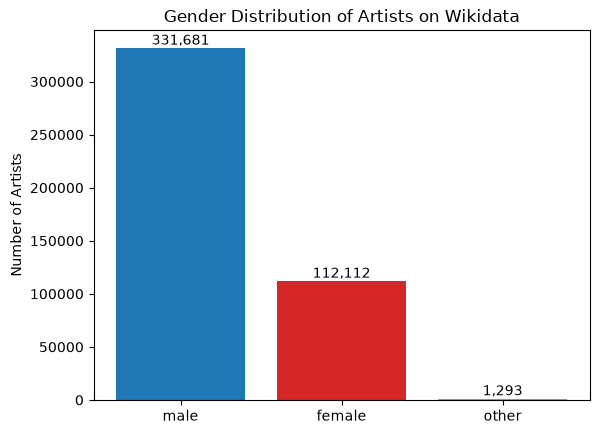

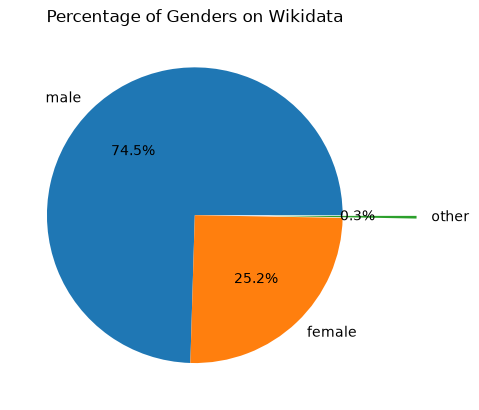

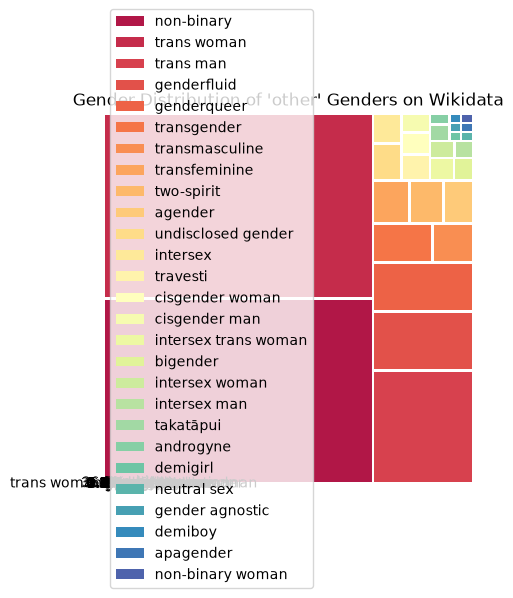

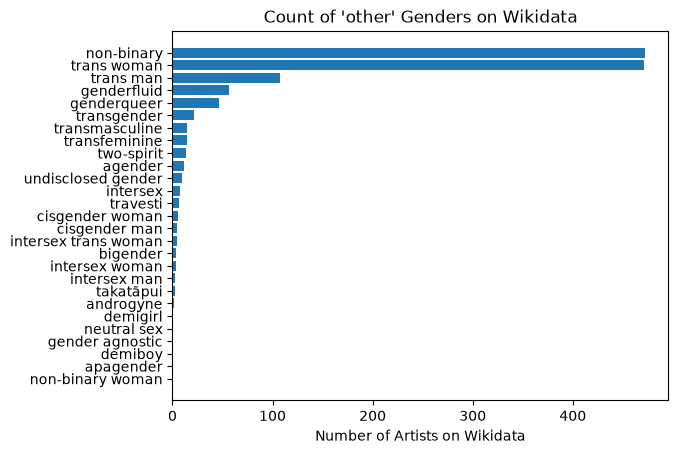

In [180]:
men_women = artistGenderGrouped[0:2]
print(men_women)
other_genders = artistGenderGrouped[2:].drop_nulls().select(pl.col("artist")).sum()
print(other_genders)
dfOthers = pl.DataFrame({"gender":None,"genderLabel":"other", "artist":other_genders.item(0,0)})
genderList = men_women["genderLabel"].to_list()
genderList.extend(dfOthers["genderLabel"].to_list())
print(genderList)
countList = men_women["artist"].to_list()
countList.extend(dfOthers["artist"].to_list())
print(countList)
makeBarChart(genderList, countList, "Gender Distribution of Artists on Wikidata", "Number of Artists" )
makePieChart2(genderList, countList, "Percentage of Genders on Wikidata", (0, 0 , 0.5))


other_genders_forBar = artistGenderGrouped[2:].drop_nulls()
makePieChart(other_genders_forBar["genderLabel"].to_list(), other_genders_forBar["artist"].to_list(), "Gender Distribution of 'other' Genders on Wikidata", "coolwarm")

makeTreeMap(other_genders_forBar["genderLabel"].to_list(), other_genders_forBar["artist"].to_list(), "Spectral","Gender Distribution of 'other' Genders on Wikidata", 100 )

horizontalBarChart(other_genders_forBar["genderLabel"].to_list(), other_genders_forBar["artist"].to_list(), "Count of 'other' Genders on Wikidata", "Number of Artists on Wikidata" )

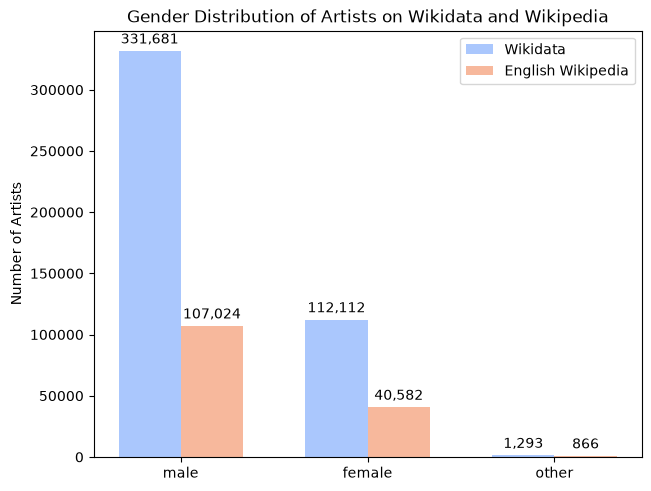

In [191]:
#Make grouped bar chart
groupBarChart(genderList,countList,countListWiki, "Gender Distribution of Artists on Wikidata and Wikipedia","Number of Artists","Wikidata", "English Wikipedia")

The artists on wikidata cover 784 countries (present and historical.


countryCitizenship,fraction
str,f64
"""Q30""",0.16646
"""Q183""",0.056916
"""Q17""",0.049299
"""Q142""",0.048774
"""Q145""",0.047671
…,…
"""Q601252""",0.000003
"""Q697084""",0.000003
"""Q3820""",0.000003


countryCitizenship,countryCitizenshipLabel,artist
str,str,u32
null,null,122946
"""Q30""","""United States""",58674
"""Q183""","""Germany""",20062
"""Q17""","""Japan""",17377
"""Q142""","""France""",17192


There are 122946 artists without a region/country
There are 321943 artists with a region/country


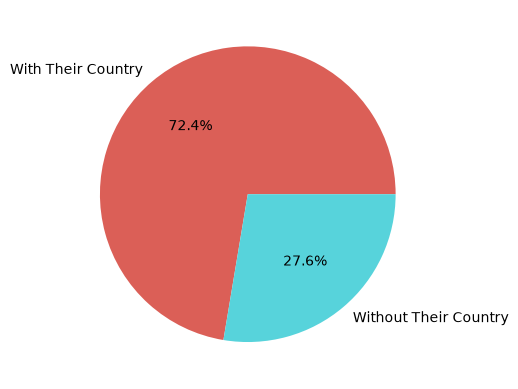

In [212]:
#Look at the region/country split of the data
regions = artistDF.select(
    pl.col("artist"),
    pl.col("countryCitizenship"),
    pl.col("countryCitizenshipLabel"),
).unique()

print(f"The artists on wikidata cover {len(regions["countryCitizenship"].unique())} countries (present and historical.")
regionsGrouped = regions.group_by(["countryCitizenship", "countryCitizenshipLabel"]).agg(pl.col("artist").count()).sort(by=pl.col("artist"),descending=True)
regionsGroupedFRAC = regions["countryCitizenship"].drop_nulls().value_counts(sort=True, normalize=True, name="fraction")
display(regionsGroupedFRAC)
regionsGrouped.write_csv("./Visuals Data/artistsGroupedByRegions-Countries.csv", null_value="null/unknown")
display(regionsGrouped.head(5))

countRegionsNull = artistDF.filter(
    pl.col("countryCitizenship").is_null()
).select(pl.col("artist")).unique()

countRegionsNotNull = artistDF.filter(
    pl.col("countryCitizenship").is_not_null()
).select(pl.col("artist")).unique()
print(f"There are {len(countRegionsNull)} artists without a region/country")
print(f"There are {len(countRegionsNotNull)} artists with a region/country")

makePieChart(["With Their Country", "Without Their Country"],[len(countRegionsNotNull),len(countRegionsNull)],"Artists With and Without Their Country of Citizenship on Wikidata", "hls")


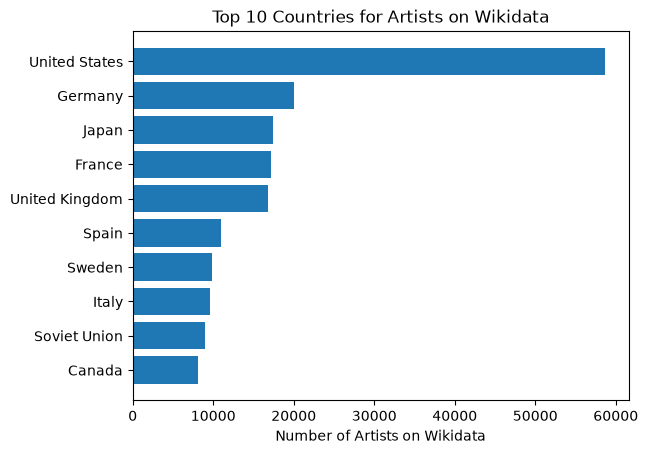

In [213]:
#Bar chart of top 10 countries
top10Regions = regionsGrouped.drop_nulls()[0:10]
horizontalBarChart(top10Regions["countryCitizenshipLabel"].to_list(), top10Regions["artist"].to_list(), "Top 10 Countries for Artists on Wikidata", "Number of Artists on Wikidata" )


The artists on Wikipedia cover 627 countries (present and historical.


countryCitizenship,fraction
str,f64
"""Q30""",0.298175
"""Q145""",0.088096
"""Q142""",0.041862
"""Q183""",0.040579
"""Q16""",0.033737
…,…
"""Q3486796""",0.000007
"""Q43937""",0.000007
"""Q465022""",0.000007


countryCitizenship,countryCitizenshipLabel,artist
str,str,u32
"""Q30""","""United States""",43926
null,null,14883
"""Q145""","""United Kingdom""",12978
"""Q142""","""France""",6167
"""Q183""","""Germany""",5978


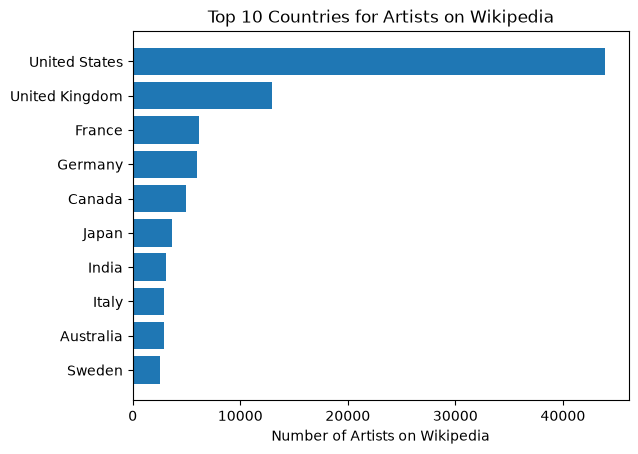

In [214]:
#top 10 regions on wikipedia

regionsWiki = artistDF.filter(pl.col("article").is_not_null()).select(
    pl.col("artist"),
    pl.col("countryCitizenship"),
    pl.col("countryCitizenshipLabel"),
).unique()

print(f"The artists on Wikipedia cover {len(regionsWiki["countryCitizenship"].unique())} countries (present and historical.")
regionsGroupedWiki = regionsWiki.group_by(["countryCitizenship", "countryCitizenshipLabel"]).agg(pl.col("artist").count()).sort(by=pl.col("artist"),descending=True)
regionsGroupedFRACWiki = regionsWiki["countryCitizenship"].drop_nulls().value_counts(sort=True, normalize=True, name="fraction")
display(regionsGroupedFRACWiki)
regionsGroupedWiki.write_csv("./Visuals Data/wikipediaArtistsGroupedByRegions-Countries.csv", null_value="null/unknown")
display(regionsGroupedWiki.head(5))

top10Regions = regionsGroupedWiki.drop_nulls()[0:10]
horizontalBarChart(top10Regions["countryCitizenshipLabel"].to_list(), top10Regions["artist"].to_list(), "Top 10 Countries for Artists on Wikipedia", "Number of Artists on Wikipedia" )


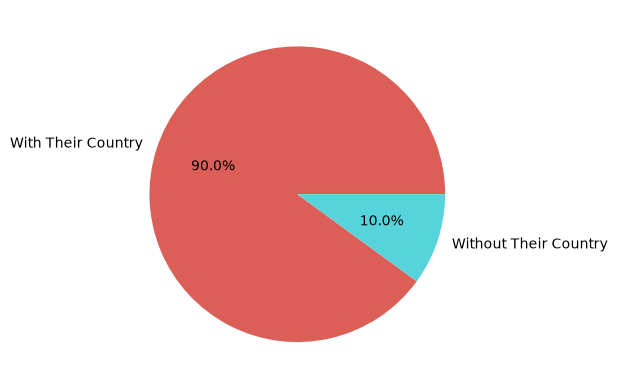

In [215]:
countRegionsNullWiki = artistDF.filter(
    pl.col("countryCitizenship").is_null(),
    pl.col("article").is_not_null(),
).select(pl.col("artist")).unique()

countRegionsNotNullWiki = artistDF.filter(
    pl.col("countryCitizenship").is_not_null(),
    pl.col("article").is_not_null()
).select(pl.col("artist")).unique()
makePieChart(["With Their Country", "Without Their Country"],[len(countRegionsNotNullWiki),len(countRegionsNullWiki)],"Artists With and Without Their Country of Citizenship on Wikipedia", "hls")

In [216]:
#Look at the genre and gender-genre split on wikidata
genresDF = artistDF.select(
    pl.col("artist"),
    pl.col("genderLabel"),
    pl.col("genre"),
    pl.col("genreLabel"),
).unique()
genresDFGrouped = genresDF.group_by(["genre", "genreLabel"]).agg(pl.col("artist").count())
genresDFGrouped.write_csv("./Visuals Data/artistsGroupedByGenres.csv", null_value="null/unknown")
display(genresDFGrouped.sample(5))
genreGenderSplit = genresDF.group_by(["genre", "genreLabel","genderLabel"]).agg(pl.col("artist").count())
print(genreGenderSplit.head())
genreGenderPivot = genreGenderSplit.pivot(
    "genderLabel",
    index = ["genre", "genreLabel"],
    values = "artist",
    aggregate_function = "sum"
)
genreGenderPivot.write_csv("./Visuals Data/artistsGroupedByGenresAndGender.csv", null_value="null/unknown")


countGenreNull = artistDF.filter(
    pl.col("genre").is_null()
).select(pl.col("artist")).unique()

countGenreNotNull = artistDF.filter(
    pl.col("genre").is_not_null()
).select(pl.col("artist")).unique()
print(f"There are {len(countGenreNull)} artists without a genre")
print(f"There are {len(countGenreNotNull)} artists with a genre")

genreGenderPivot


genre,genreLabel,artist
str,str,u32
"""Q2963337""","""Chicago hip-hop""",12
"""Q7050752""","""Nordic folk music""",3
"""Q757143""","""chill-out music""",12
"""Q2406900""","""twoubadou""",4
"""Q10922""","""hardcore punk""",190


shape: (5, 4)
┌────────────┬───────────────────┬─────────────┬────────┐
│ genre      ┆ genreLabel        ┆ genderLabel ┆ artist │
│ ---        ┆ ---               ┆ ---         ┆ ---    │
│ str        ┆ str               ┆ str         ┆ u32    │
╞════════════╪═══════════════════╪═════════════╪════════╡
│ Q108665706 ┆ corridos tumbados ┆ female      ┆ 1      │
│ Q667659    ┆ funk metal        ┆ male        ┆ 9      │
│ Q29973057  ┆ gqom              ┆ female      ┆ 2      │
│ Q116690325 ┆ power ballad      ┆ male        ┆ 1      │
│ Q1632601   ┆ nuevo tango       ┆ male        ┆ 4      │
└────────────┴───────────────────┴─────────────┴────────┘
There are 345319 artists without a genre
There are 99569 artists with a genre


genre,genreLabel,female,male,trans woman,non-binary,genderqueer,genderfluid,null,transmasculine,trans man,intersex,travesti,demiboy,undisclosed gender,bigender,intersex trans woman,agender,transgender,two-spirit,cisgender man,transfeminine,intersex man,takatāpui,cisgender woman,neutral sex,intersex woman,demigirl,gender agnostic,androgyne,non-binary woman,apagender
str,str,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""Q108665706""","""corridos tumbados""",1,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""Q667659""","""funk metal""",0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""Q29973057""","""gqom""",2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""Q116690325""","""power ballad""",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""Q1632601""","""nuevo tango""",0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Q6908884""","""mor lam sing""",1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""Q1428470""","""klapa""",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""Q1772422""","""stoner metal""",0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [217]:
#What are the different occupations
len(artistDF.select(pl.col("occupation")).drop_nulls().unique())

266

In [218]:
#Look at the occupation and occupation/gender split
occupationDF = artistDF.select(
    pl.col("artist"),
    pl.col("genderLabel"),
    pl.col("occupation"),
    pl.col("occupationLabel"),
).unique()
occupationDFDFGrouped = occupationDF.group_by(["occupation", "occupationLabel"]).agg(pl.col("artist").count())
occupationDFDFGrouped.write_csv("./Visuals Data/artistsGroupedByOccupation.csv", null_value="null/unknown")
display(occupationDFDFGrouped.sample(5))
occupationGenderSplit = occupationDF.group_by(["occupation", "occupationLabel","genderLabel"]).agg(pl.col("artist").count())

occupationGenderPivot = occupationGenderSplit.pivot(
    "genderLabel",
    index = ["occupation", "occupationLabel"],
    values = "artist",
    aggregate_function = "sum"
)

occupationGenderPivot.write_csv("./Visuals Data/artistsGroupedByOccupationAndGender.csv", null_value="null/unknown")
display(occupationGenderPivot.sample(5))

occupation,occupationLabel,artist
str,str,u32
"""Q63536580""","""video game composer""",107
"""Q3560496""","""fiddler""",749
"""Q639669""","""musician""",129173
"""Q1259917""","""violinist""",11834
"""Q110829086""","""classical flautist""",14


occupation,occupationLabel,transfeminine,non-binary,male,genderqueer,cisgender man,female,trans woman,two-spirit,takatāpui,transgender,trans man,genderfluid,agender,intersex woman,bigender,intersex trans woman,undisclosed gender,intersex,cisgender woman,transmasculine,demiboy,null,intersex man,non-binary woman,travesti,gender agnostic,androgyne,apagender,neutral sex,demigirl
str,str,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""Q139142334""","""classical oboist""",0,0,24,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""Q62747204""","""big band musician""",0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""Q2477135""","""lÄƒutar""",0,0,14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""Q104224753""","""dansband musician""",0,0,18,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""Q16156383""","""tubist""",0,0,173,0,0,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Old Code that I will ignore for now

In [219]:
cleanedArtistDF = artistDF.filter(
    ~pl.col("artist").is_in(pl.col("artistLabel").implode()),
    ~pl.col("influencedBY").is_in(pl.col("influencedBYLabel").implode()),
    ~pl.col("recordLabel").is_in(pl.col("recordLabelLabel").implode()),
    ~pl.col("genre").is_in(pl.col("genreLabel").implode()),
)

#Add a column for presence of wikiPage
cleanedArtistDF = cleanedArtistDF.with_columns(
    isThereAWiki = pl.col("article").is_not_null()
)
#Finally de-duplicate the data.
cleanedArtistDF = cleanedArtistDF.unique()
display(cleanedArtistDF.head(5))
display(cleanedArtistDF.shape)

artist,occupation,gender,occupationLabel,genderLabel,countryCitizenship,influencedBY,influencedBYLabel,statementCount,genre,article,musicBrainzID,recordLabel,recordLabelLabel,countryCitizenshipLabel,genreLabel,artistLabel,isThereAWiki
str,str,str,str,str,str,str,str,f64,str,str,str,str,str,str,str,str,bool
"""Q7542""","""Q855091""","""Q6581097""","""guitarist""","""male""","""Q30""","""Q819016""","""Carlos Santana""",380.0,"""Q484641""","""https://en.wikipedia.org/wiki/…","""d90f9497-deac-4ce3-9cd2-e2c4f4…","""Q2280168""","""Paisley Park Records""","""United States""","""pop rock""","""Prince""",true
"""Q45909""","""Q36834""","""Q6581097""","""composer""","""male""","""Q145""","""Q48173""","""Bedřich Smetana""",294.0,"""Q484641""","""https://en.wikipedia.org/wiki/…","""72c090b6-a68e-4cb9-b330-852786…","""Q645889""","""Reprise Records""","""United Kingdom""","""pop rock""","""John Cale""",true
"""Q7542""","""Q855091""","""Q6581097""","""guitarist""","""male""","""Q30""","""Q5928""","""Jimi Hendrix""",380.0,"""Q6868046""","""https://en.wikipedia.org/wiki/…","""d651d80e-6137-4440-81da-fff5a2…","""Q843402""","""Warner Bros. Records""","""United States""","""Minneapolis sound""","""Prince""",true
"""Q318475""","""Q36834""","""Q6581097""","""composer""","""male""","""Q30""","""Q128746""","""Irving Berlin""",288.0,"""Q11399""","""https://en.wikipedia.org/wiki/…","""da7bb7d8-557d-4635-9ca1-e6e985…","""Q843402""","""Warner Bros. Records""","""United States""","""rock music""","""Randy Newman""",true
"""Q5383""","""Q753110""","""Q6581097""","""songwriter""","""male""","""Q145""","""Q392""","""Bob Dylan""",487.0,"""Q9778""","""https://en.wikipedia.org/wiki/…","""5441c29d-3602-4898-b1a1-b77fa2…","""Q557632""","""Decca""","""United Kingdom""","""electronic music""","""David Bowie""",true


(137036, 18)

That is the end of the cleaning stage. Now time to analyse the data. Null values were left intentionally as we are looking for the gaps

In [220]:
#Discover the gender gap in the set.
artistsByGender = cleanedArtistDF.select(
    pl.col("artist"),
    pl.col("gender"),
    pl.col("genderLabel"),
)
artistsByGender = artistsByGender.unique()
artistGenderGrouped = artistsByGender.group_by(["gender", "genderLabel"]).agg(pl.col("artist").count())
artistGenderGroupedFRAC = artistsByGender["genderLabel"].value_counts(sort=True, normalize=True, name="fraction")
display(artistGenderGrouped)
display(artistGenderGroupedFRAC)

gender,genderLabel,artist
str,str,u32
"""Q1052281""","""trans woman""",1
"""Q18116794""","""genderfluid""",4
"""Q27679684""","""transfeminine""",1
"""Q48270""","""non-binary""",5
"""Q6581072""","""female""",188
"""Q6581097""","""male""",305


genderLabel,fraction
str,f64
"""male""",0.605159
"""female""",0.373016
"""non-binary""",0.009921
"""genderfluid""",0.007937
"""transfeminine""",0.001984
"""trans woman""",0.001984


In [221]:
genderChart = (
    alt.Chart(artistGenderGrouped).mark_bar().encode(
    y="artist",
    x="genderLabel",
    )
    .properties(width=500, title="Gender Distribution of Wikidata")
)
genderChart.encoding.x.title = "Genders"
genderChart.encoding.y.title = "Counts"
genderChart.show()



genderBase = alt.Chart(artistGenderGrouped).encode(
    alt.Theta("artist:Q").stack(True),
    alt.Color("genderLabel:N").legend(None)
    )
pie = genderBase.mark_arc(outerRadius=120)
text = genderBase.mark_text(radius=140, size=20).encode(text="genderLabel:N")
pie+text

alt.Chart(...)

alt.LayerChart(...)

In [222]:
#Top genres and genre gap

In [223]:
#Top occupations

In [224]:
#Top occupations by gender

In [225]:
#Gender and genre split